Assignment 1 - Part 1 : Classification using K-Nearest Neighbors (KNN)

The goal of this task is to perform a classification problem using Telescope dataset with the K-Nearest Neighbors (KNN) algorithm.

We will:
Balance the dataset.
Split it into training, validation, and testing sets (70%, 15%, 15%).
Implement KNN manually (from scratch).
Re-implement using Scikit-Learn.
Tune the parameter k and plot validation accuracy.
Compare both implementations.
Evaluate with accuracy, precision, recall, F1-score, and confusion matrix.
Discuss overfitting and underfitting behavior.

Importing Libraries

In [8]:
import csv
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Load and Explore the Dataset

In [9]:
df=pd.read_csv("telescope_data.csv")

print(df.head())
print(f"Rows= {df.shape[0]}")
print(f"Columns= {df.shape[1]}")



   Unnamed: 0   fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  \
0           0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   
1           1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   
2           2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580   
3           3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   
4           4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   

   fM3Trans   fAlpha     fDist class  
0   -8.2027  40.0920   81.8828     g  
1   -9.9574   6.3609  205.2610     g  
2  -45.2160  76.9600  256.7880     g  
3   -7.1513  10.4490  116.7370     g  
4   21.8393   4.6480  356.4620     g  
Rows= 19020
Columns= 12


Data Cleaning

We remove:
Duplicate rows
Missing values
Unused columns (like Unnamed: 0)
to ensure data consistency.

In [10]:
df.drop_duplicates()
df.dropna(axis=0)
#axis=1 columns axis=0 rows

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...,...
19015,19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [ ]:
# Remove the unnecessary index column automatically added during CSV saving
df.drop(columns=['Unnamed: 0'], inplace=True)

# Display the first few rows to confirm the column was removed
df.head()

# Print the shape of the dataset (rows, columns) after cleaning
print(df.shape)

(19020, 11)


Handle Class Imbalance

The dataset contains more gamma (g) than hadron (h) events.
We will undersample the gamma class to match the hadron count.

In [12]:
gamma=df[df['class']=='g']
hadron=df[df['class']=='h']
print(gamma.shape)
print(hadron.shape)

(12332, 11)
(6688, 11)


In [ ]:
# Randomly sample rows from the 'gamma' dataset 
# so that it has the same number of rows as the 'hadron' dataset
gamma_sample = gamma.sample(hadron.shape[0], random_state=42)

# Print the shape of the sampled dataset to verify the match
print(gamma_sample.shape)


(6688, 11)


In [14]:
balanced=pd.concat([gamma_sample,hadron])
balanced=balanced.sample(frac=1,random_state=42).reset_index(drop=True)
#frac=1 -> all 100%
#drop=true drop unused rows

In [15]:
print(len(balanced[balanced['class']=='g']))

6688


Data Splitting

We split the dataset into:
70% training
15% validation
15% testing
Stratified sampling ensures class balance in each subset.

In [16]:
X=balanced.drop(columns=['class'])
Y=balanced['class']
x_train,x_temp,y_train,y_temp=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)
print(x_train.shape)
print(y_train.shape)


(9363, 10)
(9363,)


In [ ]:
# Split the temporary dataset (x_temp, y_temp) into validation and test sets
# Each gets 50% of x_temp and y_temp
# 'stratify=y_temp' ensures both sets maintain the same class distribution
x_validate, x_test, y_validate, y_test = train_test_split(
    x_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp
)

# Display the shapes of the resulting datasets to confirm correct splitting
print(x_test.shape)
print(y_test.shape)
print(x_validate.shape)
print(y_validate.shape)


(2007, 10)
(2007,)
(2006, 10)
(2006,)


Manual KNN Implementation

We now implement KNN manually:
Compute Euclidean distance
Select the K-nearest neighbors
Use majority voting for classification

In [18]:
def eclidean_distance(x1,x2):
  return np.sqrt(np.sum((x1-x2)**2))

In [ ]:
class KNN:
    def __init__(self, k=3):
        # Initialize the KNN model with the number of neighbors (k)
        self.k = k

    def fit(self, X, y):
        # Store the training features and labels as NumPy arrays
        self.X_train = X.to_numpy()
        self.y_train = y.to_numpy()

    def predict(self, X):
        predictions = []  # To store predicted labels

        # Loop through each test sample
        for x in X.to_numpy():
            # Compute Euclidean distances between this test point and all training points
            distances = [eclidean_distance(x, x_train) for x_train in self.X_train]

            # Get indices of the k nearest neighbors (smallest distances)
            k_indices = np.argsort(distances)[:self.k]

            # Retrieve the labels of these k nearest neighbors
            k_nearest_labels = self.y_train[k_indices]

            # Perform majority voting to decide the predicted label
            label = max(set(k_nearest_labels), key=list(k_nearest_labels).count)

            # Store the prediction
            predictions.append(label)

        # Return predictions as a NumPy array
        return np.array(predictions)


In [14]:

knn = KNN(k=5)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_validate)

accuracy = np.mean(y_pred == y_validate.to_numpy())
print(f"Validation Accuracy: {accuracy:.4f}")


Validation Accuracy: 0.7692


Validate Manual KNN and Tune k

We test multiple odd k-values (up to √n) to find the best k.

In [15]:
n=len(x_train)
k_max=int(np.sqrt(n))
k_values=range(1,k_max+1,2)
accuracies = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_validate)
    acc = np.mean(y_pred == y_validate.to_numpy())
    accuracies.append(acc)
    print(f"k = {k}, Validation Accuracy = {acc:.4f}")

# Best k
best_k = k_values[np.argmax(accuracies)]
print(f"\n Best k = {best_k} with accuracy = {max(accuracies):.4f}")

k = 1, Validation Accuracy = 0.7453
k = 3, Validation Accuracy = 0.7557
k = 5, Validation Accuracy = 0.7692
k = 7, Validation Accuracy = 0.7742
k = 9, Validation Accuracy = 0.7762
k = 11, Validation Accuracy = 0.7737
k = 13, Validation Accuracy = 0.7687
k = 15, Validation Accuracy = 0.7697
k = 17, Validation Accuracy = 0.7717
k = 19, Validation Accuracy = 0.7732
k = 21, Validation Accuracy = 0.7732
k = 23, Validation Accuracy = 0.7712
k = 25, Validation Accuracy = 0.7687
k = 27, Validation Accuracy = 0.7717
k = 29, Validation Accuracy = 0.7757
k = 31, Validation Accuracy = 0.7767
k = 33, Validation Accuracy = 0.7762
k = 35, Validation Accuracy = 0.7752
k = 37, Validation Accuracy = 0.7812
k = 39, Validation Accuracy = 0.7742
k = 41, Validation Accuracy = 0.7782
k = 43, Validation Accuracy = 0.7802
k = 45, Validation Accuracy = 0.7772
k = 47, Validation Accuracy = 0.7742
k = 49, Validation Accuracy = 0.7792
k = 51, Validation Accuracy = 0.7722
k = 53, Validation Accuracy = 0.7757
k = 55

Plot Validation Accuracy (Manual KNN)

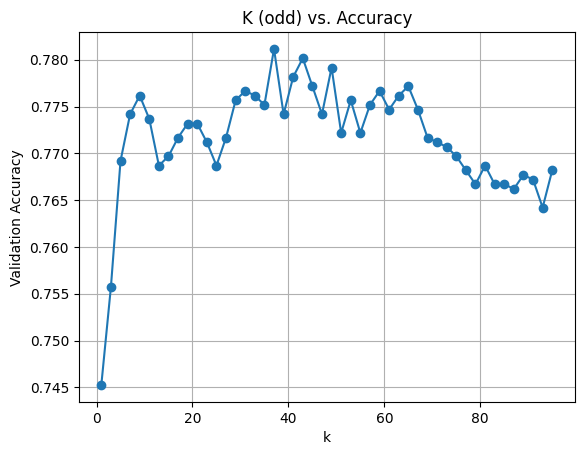

In [16]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('K (odd) vs. Accuracy')
plt.grid(True)
plt.show()

Z-Normalization

In [ ]:
# Apply Z-score normalization to each feature:
# Subtract the mean and divide by the standard deviation (column-wise)
x_z_norm = (X - X.mean(axis=0)) / X.std(axis=0)

# Split the normalized data into 70% training and 30% temporary (for validation + test)
x_z_norm_train, x_z_norm_temp, y_z_norm_train, y_z_norm_temp = train_test_split(
    x_z_norm, Y, 
    test_size=0.3, 
    random_state=42, 
    stratify=Y  # preserve class proportions
)

# Split the temporary set equally into 15% validation and 15% test
x_z_norm_validate, x_z_norm_test, y_z_norm_validate, y_z_norm_test = train_test_split(
    x_z_norm_temp, y_z_norm_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_z_norm_temp
)


Visualizing how z-Normalization Chabge the data
Before normalization, some features have very different ranges, which can bias distance-based algorithms like KNN.
After applying Z-score normalization, all features are rescaled around mean = 0 and standard deviation = 1.


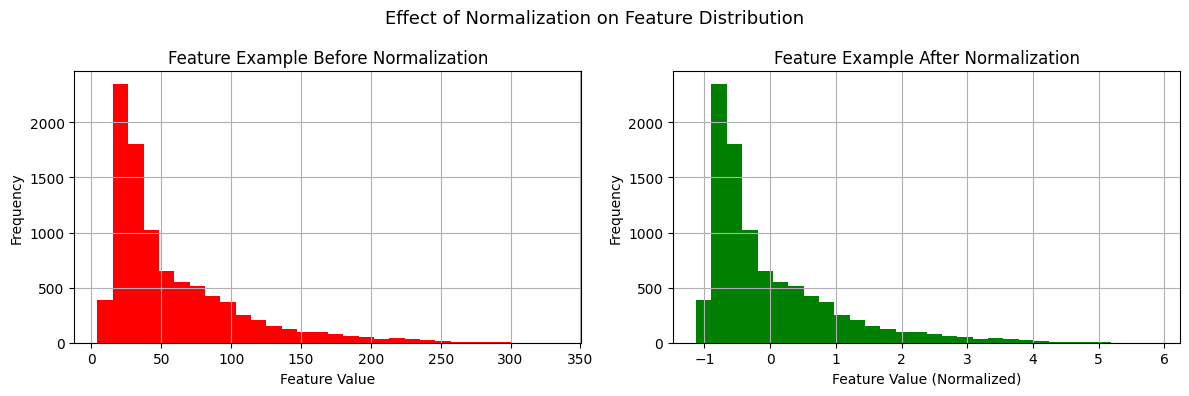

In [ ]:
# Create a figure with two side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# --- Before Normalization ---
# Plot the distribution of the first feature in its original scale
x_train.iloc[:, 0].hist(ax=ax[0], bins=30, color='red')
ax[0].set_title('Feature Example Before Normalization')
ax[0].set_xlabel('Feature Value')
ax[0].set_ylabel('Frequency')

# --- After Normalization ---
# Plot the same feature after Z-score normalization
x_z_norm_train.iloc[:, 0].hist(ax=ax[1], bins=30, color='green')
ax[1].set_title('Feature Example After Normalization')
ax[1].set_xlabel('Feature Value (Normalized)')
ax[1].set_ylabel('Frequency')

# Add a main title for both plots and adjust layout
plt.suptitle('Effect of Normalization on Feature Distribution', fontsize=13)
plt.tight_layout()
plt.show()


Manual KNN with Normalized Data

We repeat KNN on normalized features for fairer distance calculation.

In [18]:
n=len(x_z_norm_train)
k_max=int(np.sqrt(n))
k_values=range(1,k_max+1,2)
accuracies_z_norm = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(x_z_norm_train, y_z_norm_train)
    y_z_norm_pred = knn.predict(x_z_norm_validate)
    acc = np.mean(y_z_norm_pred == y_z_norm_validate.to_numpy())
    accuracies_z_norm.append(acc)
    print(f"k = {k}, Validation Accuracy = {acc:.4f}")

# Best k
best_k_z_norm = k_values[np.argmax(accuracies_z_norm)]
print(f"\nBest k = {best_k_z_norm} with accuracy = {max(accuracies_z_norm):.4f}")

k = 1, Validation Accuracy = 0.7971
k = 3, Validation Accuracy = 0.8121
k = 5, Validation Accuracy = 0.8175
k = 7, Validation Accuracy = 0.8180
k = 9, Validation Accuracy = 0.8161
k = 11, Validation Accuracy = 0.8225
k = 13, Validation Accuracy = 0.8156
k = 15, Validation Accuracy = 0.8156
k = 17, Validation Accuracy = 0.8166
k = 19, Validation Accuracy = 0.8136
k = 21, Validation Accuracy = 0.8146
k = 23, Validation Accuracy = 0.8121
k = 25, Validation Accuracy = 0.8111
k = 27, Validation Accuracy = 0.8106
k = 29, Validation Accuracy = 0.8131
k = 31, Validation Accuracy = 0.8166
k = 33, Validation Accuracy = 0.8126
k = 35, Validation Accuracy = 0.8131
k = 37, Validation Accuracy = 0.8116
k = 39, Validation Accuracy = 0.8111
k = 41, Validation Accuracy = 0.8096
k = 43, Validation Accuracy = 0.8116
k = 45, Validation Accuracy = 0.8081
k = 47, Validation Accuracy = 0.8046
k = 49, Validation Accuracy = 0.8031
k = 51, Validation Accuracy = 0.8051
k = 53, Validation Accuracy = 0.8046
k = 55

Plot Validation Accuracy (Manual with Normalization)

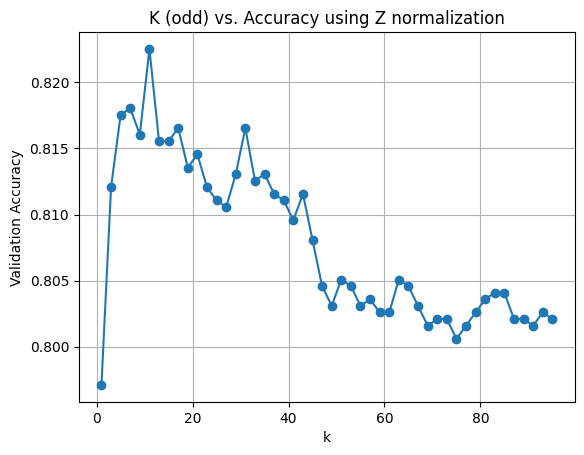

In [19]:
plt.plot(k_values, accuracies_z_norm, marker='o')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('K (odd) vs. Accuracy using Z normalization')
plt.grid(True)
plt.show()

Apply KNN using Scikit-Learn

We now use KNeighborsClassifier for comparison.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(x_z_norm_train, y_z_norm_train)
y_pred = knn.predict(x_z_norm_validate)
acc = accuracy_score(y_z_norm_validate, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8225


It generates same accuracy as our implementation

Sklearn model with no normalization

In [20]:
n=len(x_z_norm_train)
k_max=int(np.sqrt(n))
k_values=range(1,k_max+1,2)
accuracies_sklearn_non_norm = []
for k in k_values:
    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train on training data
    knn.fit(x_train, y_train)
    
    # Validate on validation set
    y_val_pred = knn.predict(x_validate)
    
    # Compute accuracy
    acc = accuracy_score(y_validate, y_val_pred)
    accuracies_sklearn_non_norm.append(acc)
    print(f"k = {k}, Validation Accuracy = {acc:.4f}")

# Find best k
best_k_sklearn_non_norm = k_values[np.argmax(accuracies_sklearn_non_norm)]
print(f"\nBest k = {best_k_sklearn_non_norm} with accuracy = {max(accuracies_sklearn_non_norm):.4f}")

k = 1, Validation Accuracy = 0.7453
k = 3, Validation Accuracy = 0.7557
k = 5, Validation Accuracy = 0.7692
k = 7, Validation Accuracy = 0.7742
k = 9, Validation Accuracy = 0.7762
k = 11, Validation Accuracy = 0.7737
k = 13, Validation Accuracy = 0.7687
k = 15, Validation Accuracy = 0.7697
k = 17, Validation Accuracy = 0.7717
k = 19, Validation Accuracy = 0.7732
k = 21, Validation Accuracy = 0.7732
k = 23, Validation Accuracy = 0.7712
k = 25, Validation Accuracy = 0.7687
k = 27, Validation Accuracy = 0.7717
k = 29, Validation Accuracy = 0.7757
k = 31, Validation Accuracy = 0.7767
k = 33, Validation Accuracy = 0.7762
k = 35, Validation Accuracy = 0.7752
k = 37, Validation Accuracy = 0.7812
k = 39, Validation Accuracy = 0.7742
k = 41, Validation Accuracy = 0.7782
k = 43, Validation Accuracy = 0.7802
k = 45, Validation Accuracy = 0.7772
k = 47, Validation Accuracy = 0.7742
k = 49, Validation Accuracy = 0.7792
k = 51, Validation Accuracy = 0.7722
k = 53, Validation Accuracy = 0.7757
k = 55

Plot Validation Accuracy (Sklearn KNN without Normalization)

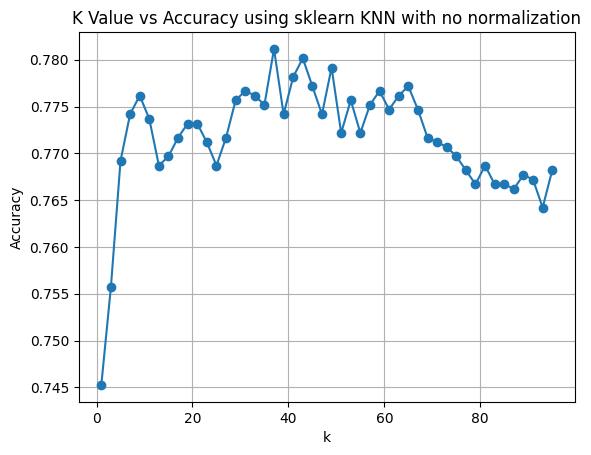

In [22]:
plt.plot(k_values, accuracies_sklearn_non_norm, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy using sklearn KNN with no normalization')
plt.grid(True)
plt.show()


Sklearn model with Z-normalization

In [ ]:
accuracies_sklearn = []
for k in k_values:
    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train on training data
    knn.fit(x_z_norm_train, y_z_norm_train)
    
    # Validate on validation set
    y_val_pred = knn.predict(x_z_norm_validate)
    
    # Compute accuracy
    acc = accuracy_score(y_z_norm_validate, y_val_pred)
    accuracies_sklearn.append(acc)
    print(f"k = {k}, Validation Accuracy = {acc:.4f}")

# Find best k
best_k_sklearn = k_values[np.argmax(accuracies_sklearn)]
print(f"\nBest k = {best_k_sklearn} with accuracy = {max(accuracies_sklearn):.4f}")

k = 1, Validation Accuracy = 0.7971
k = 3, Validation Accuracy = 0.8121
k = 5, Validation Accuracy = 0.8175
k = 7, Validation Accuracy = 0.8180
k = 9, Validation Accuracy = 0.8161
k = 11, Validation Accuracy = 0.8225
k = 13, Validation Accuracy = 0.8156
k = 15, Validation Accuracy = 0.8156
k = 17, Validation Accuracy = 0.8166
k = 19, Validation Accuracy = 0.8136
k = 21, Validation Accuracy = 0.8146
k = 23, Validation Accuracy = 0.8121
k = 25, Validation Accuracy = 0.8111
k = 27, Validation Accuracy = 0.8106
k = 29, Validation Accuracy = 0.8131
k = 31, Validation Accuracy = 0.8166
k = 33, Validation Accuracy = 0.8126
k = 35, Validation Accuracy = 0.8131
k = 37, Validation Accuracy = 0.8116
k = 39, Validation Accuracy = 0.8111
k = 41, Validation Accuracy = 0.8096
k = 43, Validation Accuracy = 0.8116
k = 45, Validation Accuracy = 0.8081
k = 47, Validation Accuracy = 0.8046
k = 49, Validation Accuracy = 0.8031
k = 51, Validation Accuracy = 0.8051
k = 53, Validation Accuracy = 0.8046
k = 55

Plot Validation Accuracy (Sklearn KNN with Normalization)

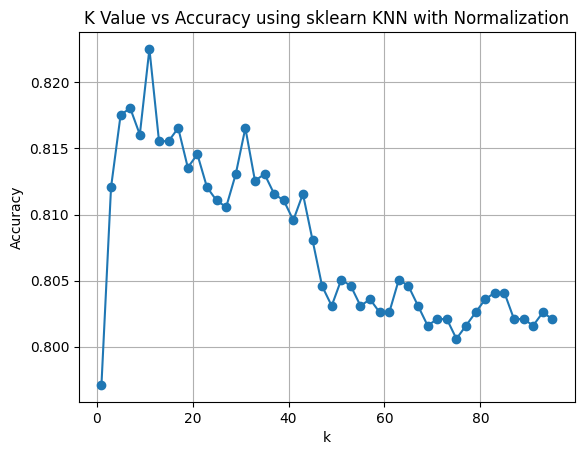

In [25]:
plt.plot(k_values, accuracies_sklearn, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy using sklearn KNN with Normalization')
plt.grid(True)
plt.show()


Effect of Normalization on accuracy

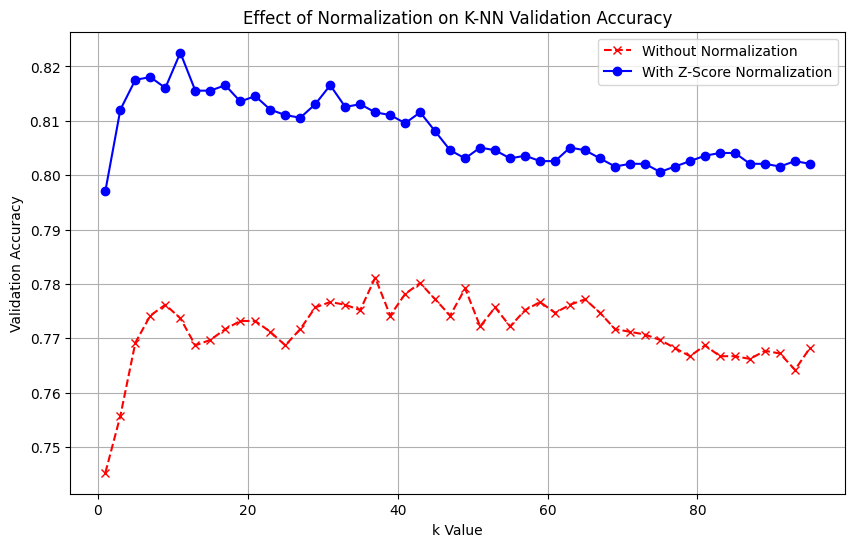

In [24]:
# --- Plotting to Compare Normalization Effect ---
plt.figure(figsize=(10, 6))

# Plot accuracy without normalization
plt.plot(k_values, accuracies_sklearn_non_norm, marker='x', linestyle='--', label='Without Normalization', color='red')

# Plot accuracy with normalization
plt.plot(k_values, accuracies_sklearn, marker='o', label='With Z-Score Normalization', color='blue')

plt.title('Effect of Normalization on K-NN Validation Accuracy')
plt.xlabel('k Value')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Trying another distance calculation function as manhattan and check accuracies
Manhattan distance = sum(abs(x1-x2))

In [30]:
n=len(x_z_norm_train)
k_max=int(np.sqrt(n))
k_values=range(1,k_max+1,2)
accuracies_sklearn_manhattan= []
for k in k_values:
    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k,metric="manhattan")
    #sum(abs(x1 - x2))
    
    # Train on training data
    knn.fit(x_train, y_train)
    
    # Validate on validation set
    y_val_pred = knn.predict(x_validate)
    
    # Compute accuracy
    acc = accuracy_score(y_validate, y_val_pred)
    accuracies_sklearn_manhattan.append(acc)
    print(f"k = {k}, Validation Accuracy = {acc:.4f}")

# Find best k
best_k_sklearn_manhattan = k_values[np.argmax(accuracies_sklearn_manhattan)]
print(f"\nBest k = {best_k_sklearn_manhattan} with accuracy = {max(accuracies_sklearn_manhattan):.4f}")

k = 1, Validation Accuracy = 0.7498
k = 3, Validation Accuracy = 0.7642
k = 5, Validation Accuracy = 0.7747
k = 7, Validation Accuracy = 0.7807
k = 9, Validation Accuracy = 0.7861
k = 11, Validation Accuracy = 0.7876
k = 13, Validation Accuracy = 0.7846
k = 15, Validation Accuracy = 0.7832
k = 17, Validation Accuracy = 0.7856
k = 19, Validation Accuracy = 0.7861
k = 21, Validation Accuracy = 0.7866
k = 23, Validation Accuracy = 0.7846
k = 25, Validation Accuracy = 0.7861
k = 27, Validation Accuracy = 0.7856
k = 29, Validation Accuracy = 0.7871
k = 31, Validation Accuracy = 0.7841
k = 33, Validation Accuracy = 0.7871
k = 35, Validation Accuracy = 0.7866
k = 37, Validation Accuracy = 0.7861
k = 39, Validation Accuracy = 0.7861
k = 41, Validation Accuracy = 0.7866
k = 43, Validation Accuracy = 0.7876
k = 45, Validation Accuracy = 0.7856
k = 47, Validation Accuracy = 0.7851
k = 49, Validation Accuracy = 0.7817
k = 51, Validation Accuracy = 0.7777
k = 53, Validation Accuracy = 0.7802
k = 55

Plotting Accuracies

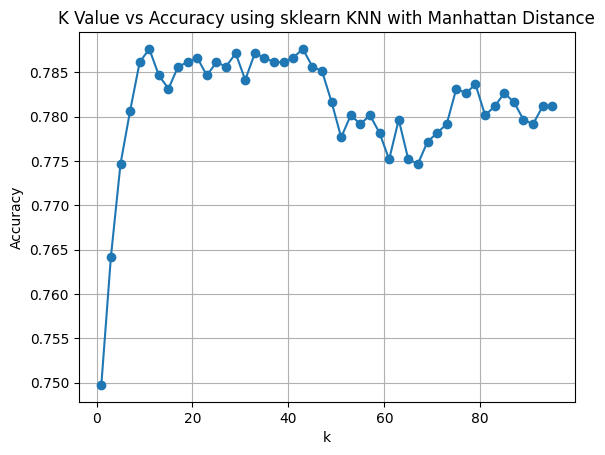

In [31]:
plt.plot(k_values, accuracies_sklearn_manhattan, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy using sklearn KNN with Manhattan Distance')
plt.grid(True)
plt.show()

Comparing between Validation accuracies using euclidean distance and manhattan distance

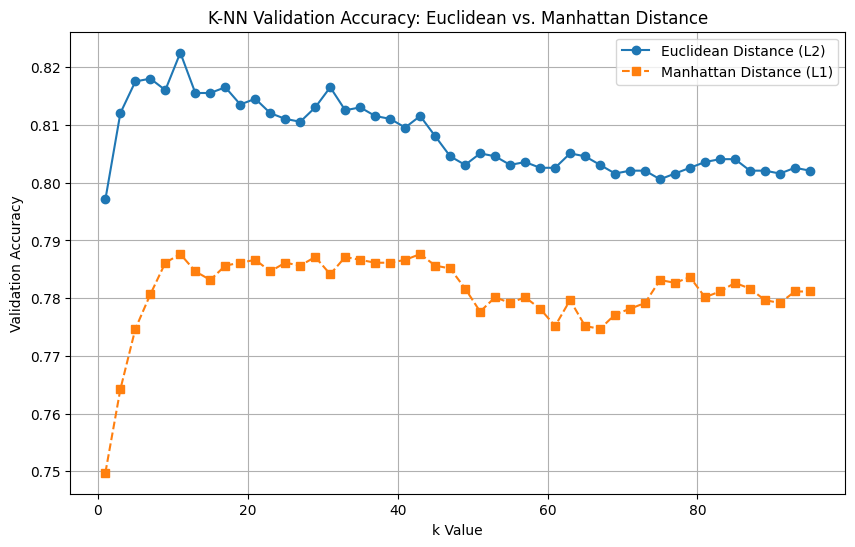

In [ ]:
# Create a new figure for comparing KNN performance using two distance metrics
plt.figure(figsize=(10, 6))

# Plot validation accuracy using Euclidean distance (L2 norm)
plt.plot(k_values, accuracies_sklearn, marker='o', label='Euclidean Distance (L2)')

# Plot validation accuracy using Manhattan distance (L1 norm)
plt.plot(k_values, accuracies_sklearn_manhattan, marker='s', linestyle='--', label='Manhattan Distance (L1)')

# Add labels, title, and legend for clarity
plt.title('K-NN Validation Accuracy: Euclidean vs. Manhattan Distance')
plt.xlabel('k Value')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


Euclidean distance has higher accuracy for the same k

Plotting validation accuracy for both implementations

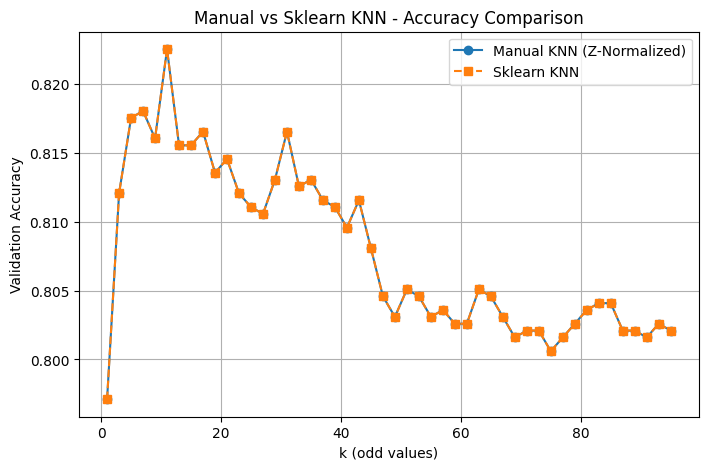

In [38]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies_z_norm, marker='o', label='Manual KNN (Z-Normalized)')
plt.plot(k_values, accuracies_sklearn, marker='s', label='Sklearn KNN', linestyle='--')
plt.xlabel('k (odd values)')
plt.ylabel('Validation Accuracy')
plt.title('Manual vs Sklearn KNN - Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()


Final Evaluation on Test Set

We evaluate both models using the test set.

In [ ]:
# --- Final Evaluation on Test Set ---
print("\n--- Final Evaluation on Test Set ---")

# ==============================
# Manual KNN Implementation
# ==============================
print("Manual KNN Implementation:")

best_k_z_norm = 11  # best k value found from validation
print(f"Best k: {best_k_z_norm}")

# Train the KNN model using the best k on normalized training data
best_knn_manual = KNeighborsClassifier(n_neighbors=best_k_z_norm)
best_knn_manual.fit(x_z_norm_train, y_z_norm_train)

# Predict on the test set
y_test_pred_manual = best_knn_manual.predict(x_z_norm_test)

# Calculate test accuracy
test_acc_manual = accuracy_score(y_z_norm_test, y_test_pred_manual)
print(f"Test Accuracy Manual Model: {test_acc_manual:.4f}")

# Show detailed performance metrics
print("\n Classification Report:")
print(classification_report(y_z_norm_test, y_test_pred_manual))

# Display confusion matrix
print(" Confusion Matrix:")
print(confusion_matrix(y_z_norm_test, y_test_pred_manual))


# ==============================
# Scikit-learn KNN Implementation
# ==============================
print("\n\nSklearn KNN Implementation:")

best_k_sklearn = 11  # best k value from validation
print(f"Best k: {best_k_sklearn}")

# Train sklearn KNN model
best_knn_sklearn = KNeighborsClassifier(n_neighbors=best_k_sklearn)
best_knn_sklearn.fit(x_z_norm_train, y_z_norm_train)

# Predict on the test set
y_test_pred_sklearn = best_knn_sklearn.predict(x_z_norm_test)

# Calculate accuracy
test_acc_sklearn = accuracy_score(y_z_norm_test, y_test_pred_sklearn)
print(f"Test Accuracy Sklearn Model: {test_acc_sklearn:.4f}")

# Show detailed classification metrics
print("\n Classification Report:")
print(classification_report(y_z_norm_test, y_test_pred_sklearn))

# Display confusion matrix
print(" Confusion Matrix:")
print(confusion_matrix(y_z_norm_test, y_test_pred_sklearn))



--- Final Evaluation on Test Set ---
Manual KNN Implementation:
Best k: 11
Test Accuracy Manual Model: 0.8266

 Classification Report:
              precision    recall  f1-score   support

           g       0.78      0.90      0.84      1004
           h       0.89      0.75      0.81      1003

    accuracy                           0.83      2007
   macro avg       0.83      0.83      0.83      2007
weighted avg       0.83      0.83      0.83      2007

 Confusion Matrix:
[[907  97]
 [251 752]]


Sklearn KNN Implementation:
Best k: 11
Test Accuracy Sklearn Model: 0.8266

 Classification Report:
              precision    recall  f1-score   support

           g       0.78      0.90      0.84      1004
           h       0.89      0.75      0.81      1003

    accuracy                           0.83      2007
   macro avg       0.83      0.83      0.83      2007
weighted avg       0.83      0.83      0.83      2007

 Confusion Matrix:
[[907  97]
 [251 752]]


Results Summary

In [28]:
summary = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Manual KNN": [test_acc_manual],
    "Sklearn KNN": [test_acc_sklearn]
})
display(summary)


,Metric,Manual KNN,Sklearn KNN
0,Accuracy,0.826607,0.826607


Training vs Testing Accuracy Visualization

This plot compares training and testing accuracy across different k values.
It helps visualize:
Overfitting (training >> testing for small k)
Underfitting (both low for large k)
Optimal k region (balanced accuracies)

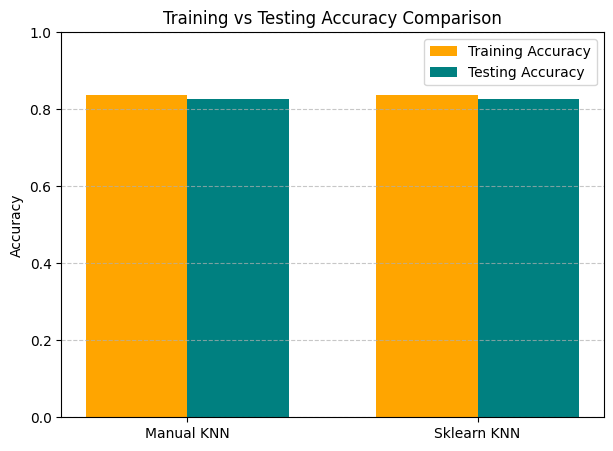

In [ ]:
# --- Evaluate both KNN models on training and test sets ---
train_acc_manual = accuracy_score(y_z_norm_train, best_knn_manual.predict(x_z_norm_train))
train_acc_sklearn = accuracy_score(y_z_norm_train, best_knn_sklearn.predict(x_z_norm_train))

# Prepare accuracy values for comparison
labels = ['Manual KNN', 'Sklearn KNN']
train_acc = [train_acc_manual, train_acc_sklearn]
test_acc = [test_acc_manual, test_acc_sklearn]

x = np.arange(len(labels))
width = 0.35  # width of each bar

# --- Bar Plot: Training vs Testing Accuracy ---
plt.figure(figsize=(7, 5))
plt.bar(x - width/2, train_acc, width, label='Training Accuracy', color='orange')
plt.bar(x + width/2, test_acc, width, label='Testing Accuracy', color='teal')

# Add labels, title, and legend
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy Comparison')
plt.legend()

# Set limits and add grid lines for clarity
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


Analysis and Discussion

Optimal k-values:
Manual KNN (normalized): k = 11
Sklearn KNN: k = 11
Overfitting/Underfitting Behavior:
Small k (e.g., 1) → high variance, overfitting.
Large k → overly smooth decision boundary, underfitting.
The optimal k provides a balance between bias and variance.
Effect of Normalization:
Features with larger numeric ranges dominated distance calculations before normalization.
After normalization, all features contributed equally, improving accuracy.

Manual vs. Sklearn:
Sklearn is optimized and faster.
Manual KNN gave identical results, proving correct understanding of the algorithm.

Conclusion: Both manual and Scikit-Learn implementations perform consistently.
Normalization significantly improves accuracy, and tuning k prevents under/overfitting.